# 4. Gene Embedding Extraction

Extract **cell / gene embeddings** from the masking checkpoint on **all LPS cells** (`--split False`).

| Setting | Value |
|---|---|
| ckpt | `masking_split/...20260808_2325...epoch=49.ckpt` |
| split | `False` (every paired cell; not the frozen 10% test set) |
| context_mode | `True` (must match training) |
| GPUs | **GPU 7** (embedding dump is not DDP-safe) |
| outputs | sod2: `.../res/masking_original_paper/embeddings_full_atlas` (already dumped 16 Aug) |

This masking run was trained with a frozen train/val/test split. The atlas extract includes cells seen in training. That is intentional.

**Do not re-dump** if `embeddings_full_atlas/...inference_embs...h5ad` is already there (16 Aug, 69531 cells).

Metrics-only test lives in notebook 03 §3.4. This notebook does **not** report MLM loss (`return_embeddings=True` -> `not_masked`).

Dump is skipped if the 16 Aug atlas h5ad exists. **§4.6 analyses** (UMAP, Leiden, cell-type probe) run on that full extract — no test-split filter, no row subsample.


## 4.1. Parameters

Update GPU id if 7 is busy. `--split False` dumps every cell; `SPLIT_PATH` is unused for the extract.


In [4]:
import os
from pathlib import Path

WORKSPACE = Path("/home/stuke1/perturbgen")
REPO = WORKSPACE / "Perturbgen"
TOKENIZED = WORKSPACE / "T_perturb" / "tokenized_data" / "LPS_all_tps_2k"
SOD2_ROOT = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")

# Single GPU for embedding extract (val.py also forces n_devices=1)
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_DIR"] = str(SOD2_ROOT / "wandb")
os.environ["TMPDIR"] = str(SOD2_ROOT / "tmp")
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["HWLOC_COMPONENTS"] = "-gl"
os.environ["HWLOC_GL_LINUX_NVIDIA_DISABLE"] = "1"
# Keep DISPLAY for notebook plots. Extract subprocess sets Agg itself.

# New 50-epoch frozen-split ckpt (train/val/test from notebook 02 §2.6)
CKPT_MASKING_PATH = str(
    WORKSPACE
    / "T_perturb"
    / "res"
    / "masking_split"
    / "checkpoints"
    / "20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt"
)
SPLIT_PATH = str(
    TOKENIZED
    / "splits"
    / "stratified_cell_type_harmonized_seed42_80_10_10.pkl"
)

# Existing full-atlas extract (16 Aug). Do not point at the test-only paper_v1 folder.
OUTPUT_DIR_PATH = (
    SOD2_ROOT / "T_perturb" / "res"
    / "masking_original_paper" / "embeddings_full_atlas"
)
OUTPUT_DIR = str(OUTPUT_DIR_PATH)
EXPECTED_INFERENCE_H5AD = str(
    OUTPUT_DIR_PATH
    / "20260816-14:10_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad"
)
assert OUTPUT_DIR.startswith("/mnt/sod2-project/csb4"), (
    f"OUTPUT_DIR must be on sod2, got {OUTPUT_DIR}"
)

SRC_DATASET = str(TOKENIZED / "dataset_2000_hvg_src" / "normal.dataset")
TGT_DATASET_FOLDER = str(TOKENIZED / "dataset_2000_hvg_tgt")
SRC_ADATA = str(TOKENIZED / "h5ad_pairing_2000_hvg_src" / "normal.h5ad")
TGT_ADATA_FOLDER = str(TOKENIZED / "h5ad_pairing_2000_hvg_tgt")
MAPPING_DICT_PATH = str(TOKENIZED / "token_id_to_genename_2000_hvg.pkl")
TOKENID_TO_ROWID = str(TOKENIZED / "tokenid_to_rowid_2000_hvg.pkl")

ENCODER_PATH = str(
    REPO
    / "pretraining_cohort"
    / "20250709_1223_cellgen_train_masking_lr_5e-05_wd_1e-06_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_42-epoch=00.ckpt"
)

BATCH_SIZE = 32
N_WORKERS = 0
PRED_TPS = ["1", "2", "3"]  # 1=90m, 2=6h, 3=10h
VAR_LIST = ["cell_pairing_index", "time_after_LPS", "cell_type_harmonized"]

ENCODER = "scmaskgit"
CONTEXT_MODE = "True"
MASK_SCHEDULER = "pow"
POS_ENCODING_MODE = "time_pos_sin"
D_MODEL = 768
D_FF = 32
NUM_LAYERS = 6

RETURN_EMBEDDINGS = "True"
RETURN_GENE_EMBS = "True"
GENE_EMBS_CONDITION = "time_after_LPS"
RETURN_ATTN = "False"
GENERATE = "False"

for p in (CKPT_MASKING_PATH, ENCODER_PATH, SRC_DATASET, SRC_ADATA, TOKENID_TO_ROWID):
    if not Path(p).exists():
        raise FileNotFoundError(p)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
ckpt_info = Path(OUTPUT_DIR) / "ckpt_info.txt"
ckpt_info.write_text(
    "\n".join([
        f"ckpt={CKPT_MASKING_PATH}",
        "split=False (all paired cells)",
        "context_mode=True",
        "return_embeddings=True",
        "return_gene_embs=True",
        f"pred_tps={PRED_TPS}",
    ]) + "\n"
)
print("Wrote", ckpt_info)
Path(os.environ["WANDB_DIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["TMPDIR"]).mkdir(parents=True, exist_ok=True)

print("CKPT:", CKPT_MASKING_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"])
print("context_mode:", CONTEXT_MODE, "| split: False (all cells)")


Wrote /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_original_paper/embeddings_full_atlas/ckpt_info.txt
CKPT: /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
OUTPUT_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_original_paper/embeddings_full_atlas
CUDA_VISIBLE_DEVICES: 7
context_mode: True | split: False (all cells)


## 4.2. Build the command

`extract-embedding` → `perturbgen.val` → `trainer.test` on **all** paired cells (`--split False`).


In [ ]:
cmd = [
    "python", "-m", "perturbgen", "extract-embedding",
    "--test_mode", "masking",
    "--split", "False",
    "--context_mode", CONTEXT_MODE,
    "--return_embeddings", RETURN_EMBEDDINGS,
    "--return_gene_embs", RETURN_GENE_EMBS,
    "--gene_embs_condition", GENE_EMBS_CONDITION,
    "--return_attn", RETURN_ATTN,
    "--generate", GENERATE,
    "--ckpt_masking_path", CKPT_MASKING_PATH,
    "--output_dir", OUTPUT_DIR,
    "--src_dataset", SRC_DATASET,
    "--tgt_dataset_folder", TGT_DATASET_FOLDER,
    "--src_adata", SRC_ADATA,
    "--tgt_adata_folder", TGT_ADATA_FOLDER,
    "--mapping_dict_path", MAPPING_DICT_PATH,
    "--tokenid_to_rowid", TOKENID_TO_ROWID,
    "--batch_size", str(BATCH_SIZE),
    "--n_workers", str(N_WORKERS),
    "--pred_tps", *PRED_TPS,
    "--var_list", *VAR_LIST,
    "--encoder", ENCODER,
    "--encoder_path", ENCODER_PATH,
    "--mask_scheduler", MASK_SCHEDULER,
    "--pos_encoding_mode", POS_ENCODING_MODE,
    "--d_model", str(D_MODEL),
    "--d_ff", str(D_FF),
    "--num_layers", str(NUM_LAYERS),
    "--wandb_mode", "offline",
]

print(" ".join(cmd))


## 4.3. Launch

Skip this cell if the 16 Aug full-atlas h5ad already exists. Only re-run extract if that file is missing.


In [ ]:
import subprocess

assert "sod2-project" in OUTPUT_DIR, (
    f"Refusing to run: OUTPUT_DIR is not on sod2: {OUTPUT_DIR}"
)
expected = Path(EXPECTED_INFERENCE_H5AD)
if expected.is_file():
    print("Skip dump; full-atlas extract already exists:")
    print(expected)
else:
    assert Path(CKPT_MASKING_PATH).is_file()
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = os.environ["CUDA_VISIBLE_DEVICES"]
    env["WANDB_MODE"] = "offline"
    env["MPLBACKEND"] = "Agg"
    env["PYTHONUNBUFFERED"] = "1"
    print("Launching extract-embedding on GPU", env["CUDA_VISIBLE_DEVICES"])
    print("OUTPUT_DIR:", OUTPUT_DIR)
    print(" ".join(cmd))
    subprocess.run(cmd, check=True, cwd=str(WORKSPACE), env=env)
    if not expected.is_file():
        candidates = sorted(Path(OUTPUT_DIR).glob("*inference_embs*.h5ad"))
        if not candidates:
            raise FileNotFoundError(f"No inference h5ad under {OUTPUT_DIR}")
        print("Wrote", candidates[-1])
print("Done. Outputs under:", OUTPUT_DIR)


In [5]:
import os
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ.pop("MPLBACKEND", None)

%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sc.settings.set_figure_params(dpi=120, facecolor="white")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score

## 4.4. How pairing sizes work (read this before the counts)

The next cell prints the raw numbers. This section is what they mean. The model is **not** trained on one table of 223k cells. It is trained on **constructed rest → LPS tuples**.

### What one pair is

scRNA-seq destroys the cell, so we cannot follow the same cell at rest, 90m, 6h, and 10h. Pairing instead builds a **synthetic trajectory** by matching cells of the **same `cell_type_harmonized`**:

| slot | file | biological time |
|---|---|---|
| rest / src | `dataset_2000_hvg_src/normal.dataset` | unstimulated (`normal`) |
| t1 | `dataset_2000_hvg_tgt/1_90m_LPS.dataset` | 90 min LPS |
| t2 | `dataset_2000_hvg_tgt/2_6h_LPS.dataset` | 6 h LPS |
| t3 | `dataset_2000_hvg_tgt/3_10h_LPS.dataset` | 10 h LPS |

Row `i` in all four files is **one example**: rest cell `i` plus one 90m, one 6h, and one 10h partner. `context_mode=True` uses that whole tuple (rest always as context; other LPS times can be context when predicting one target).

### Two layers of `.dataset` files

| layer | path | what a row is |
|---|---|---|
| Full pool | `dataset_2000_hvg/LPS_all_tps_2k.dataset` | **one real cell**, once |
| Paired src / tgt | `dataset_2000_hvg_src` + `dataset_2000_hvg_tgt` | **one pair**, aligned by row index |

Columns on every file: `input_ids` (gene tokens), `time_after_LPS`, `cell_type_harmonized`, `cell_pairing_index`, `length`.

### Full pool: one row = one cell

These are the true census after HVG tokenization, **before** pairing:

| `time_after_LPS` | n cells |
|---|---|
| normal (rest) | 148,107 |
| 6h_LPS | 43,803 |
| 10h_LPS | 20,883 |
| 90m_LPS | 10,685 |
| **total** | **223,478** |

### Paired files: one row = one rest-sized tuple

The source is the largest time (`normal`). Pairing sizes every tgt file to **every rest cell**, so:

| dataset | `n_rows` | meaning |
|---|---|---|
| src `normal` | 148,107 | one row per rest cell |
| tgt `1_90m_LPS` | 148,107 | same rows, each a 90m partner |
| tgt `2_6h_LPS` | 148,107 | same rows, each a 6h partner |
| tgt `3_10h_LPS` | 148,107 | same rows, each a 10h partner |

`n_rows = 148,107` is **number of pairs**, not number of unique LPS cells. Each tgt file has a **single** time label (`n_time_labels = 1`).

### Why unique LPS cells drop below the pool (43k → 39k at 6h)

Stratified pairing, per cell type:

1. Take all rest cells of that type (`n_samples = n_normal`).
2. Draw that many LPS cells of the same type.
3. If there are fewer LPS cells than rest cells, draw **with replacement**.

With replacement, some LPS cells are reused many times and **some are never drawn**. Unique `cell_pairing_index` in a tgt file is “LPS cells that were picked at least once.”

All 15 cell types exist at all four times, so the “must have every time point” filter drops **zero** cells. The hole is almost entirely the lottery:

| time | cells in full pool | unique IDs in paired tgt | never sampled |
|---|---|---|---|
| 90m_LPS | 10,685 | 10,633 | 52 |
| 6h_LPS | 43,803 | 39,188 | 4,615 |
| 10h_LPS | 20,883 | 19,713 | 1,170 |
| **LPS total** | 75,371 | **69,534** | 5,837 |

6h is the largest drop because rest ≫ 6h is less extreme than rest ≫ 90m, so coverage is incomplete. Biggest 6h holes:

| cell type | rest | 6h pool | unique 6h you expect after draws |
|---|---|---|---|
| CD14 monocytes | 21,363 | 14,900 | ~11,350 |
| B cell | 10,859 | 4,621 | ~4,180 |
| regulatory T cell | 1,248 | 1,029 | ~723 |

Only hematopoietic stem cells use **without** replacement (112 6h vs 96 rest → keep 96). That is 16 cells, not the 4.6k.

### What the embedding file keeps

Extract walks **every pairing row** (`--split False`), then **`drop_duplicates(cell_idx)`** so each unique LPS cell is stored once. `drop_last=True` (batch 32) trims `148,107 → 148,096` rows and can drop a few unique IDs:

| step | n |
|---|---|
| unique LPS cells in paired tgt files | 69,534 |
| after `drop_last` + dedup (this notebook’s h5ad) | **69,531** |

The next cell **recomputes** the pool and pairing tables from disk (it does not load embeddings yet). Expect: full pool 223,478; every paired file 148,107 rows; unique tgt IDs 10,633 / 39,188 / 19,713 (sum **69,534**).


In [11]:
# Tokenized cell counts per time point (full pool + paired src/tgt), before loading embeddings.
from datasets import load_from_disk

full_pool = TOKENIZED / "dataset_2000_hvg" / "LPS_all_tps_2k.dataset"
full_ds = load_from_disk(str(full_pool))
print("Full tokenized pool:", full_pool)
print("n_rows:", len(full_ds), "columns:", full_ds.column_names)
full_time = pd.Series(full_ds["time_after_LPS"]).astype(str).value_counts()
display(full_time.to_frame("n_cells"))
print("full pool total:", int(full_time.sum()))

src_ds = load_from_disk(SRC_DATASET)
print("\nPaired src:", SRC_DATASET)
print("n_rows:", len(src_ds))
src_time = pd.Series(src_ds["time_after_LPS"]).astype(str).value_counts()
display(src_time.to_frame("n_rows"))

tgt_paths = sorted(Path(TGT_DATASET_FOLDER).glob("*.dataset"))
rows = []
for p in tgt_paths:
    ds = load_from_disk(str(p))
    times = pd.Series(ds["time_after_LPS"]).astype(str)
    pair_ids = pd.Series(ds["cell_pairing_index"])
    vc = times.value_counts()
    rows.append({
        "dataset": p.stem,
        "n_rows": len(ds),
        "unique_cell_pairing_index": int(pair_ids.nunique()),
        "n_time_labels": int(times.nunique()),
        "time_after_LPS": ", ".join(vc.index.tolist()),
    })
    print(f"\nPaired tgt {p.stem}: n_rows={len(ds)}")
    display(vc.to_frame("n_rows"))

paired_summary = pd.DataFrame(rows)
display(paired_summary)
print(
    "unique tgt pairings (union of tgt files):",
    int(paired_summary["unique_cell_pairing_index"].sum()),
)


Full tokenized pool: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg/LPS_all_tps_2k.dataset
n_rows: 223478 columns: ['input_ids', 'cell_type_harmonized', 'time_after_LPS', 'cell_pairing_index', 'length']


,n_cells
normal,148107
6h_LPS,43803
10h_LPS,20883
90m_LPS,10685


full pool total: 223478

Paired src: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_src/normal.dataset
n_rows: 148107


,n_rows
normal,148107



Paired tgt 1_90m_LPS: n_rows=148107


...

,n_rows
6h_LPS,148107



Paired tgt 3_10h_LPS: n_rows=148107


,n_rows
10h_LPS,148107


,dataset,n_rows,unique_cell_pairing_index,n_time_labels,time_after_LPS
0,1_90m_LPS,148107,10633,1,90m_LPS
1,2_6h_LPS,148107,39188,1,6h_LPS
2,3_10h_LPS,148107,19713,1,10h_LPS


unique tgt pairings (union of tgt files): 69534


In [6]:
# Load the full-atlas extract (skip dump if this file exists).
expected = Path(EXPECTED_INFERENCE_H5AD)
if expected.exists():
    h5ad_path = str(expected)
else:
    candidates = sorted(Path(OUTPUT_DIR).glob("*inference_embs*.h5ad"))
    if not candidates:
        raise FileNotFoundError(f"No inference h5ad found under {OUTPUT_DIR}")
    h5ad_path = str(candidates[-1])
    print("Warning: expected atlas file not found, using latest:", h5ad_path)

assert "embeddings_full_atlas" in h5ad_path, h5ad_path
assert "benchmark_test" not in h5ad_path, "refusing test-split extract"

adata = ad.read_h5ad(h5ad_path)

print("Loaded:", h5ad_path)
print("adata shape:", adata.shape)
print("obs columns:", list(adata.obs.columns))
print("obsm keys:", list(adata.obsm.keys()))
print("n_embedding_cells (unique pairing, full atlas):", adata.n_obs)

required_obs = ["cell_type_harmonized", "time_after_LPS", "batch", "cell_idx"]
missing_obs = [k for k in required_obs if k not in adata.obs.columns]
if missing_obs:
    raise KeyError(f"Missing required obs columns: {missing_obs}")
if "cls_embeddings" not in adata.obsm:
    raise KeyError("Expected 'cls_embeddings' in adata.obsm")

Loaded: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_original_paper/embeddings_full_atlas/20260816-14:10_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad
adata shape: (69531, 1856)
obs columns: ['cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx']
obsm keys: ['cls_embeddings']
n_embedding_cells (unique pairing, full atlas): 69531


## 4.5. Why `adata.n_obs` is ~70k, not 148k

Section 4.4 is the pairing census (unique LPS cells **69,534**). This cell is the **extract**: it walks every paired row (`--split False`), then **`drop_duplicates(cell_idx)`** (one row per unique `cell_pairing_index`). `drop_last=True` only drops an incomplete last batch. The table below should match `adata.n_obs` (**69,531**).


In [8]:
from datasets import load_from_disk

tgt_paths = sorted(Path(TGT_DATASET_FOLDER).glob("*.dataset"))
name_by_tp = {}
for p in tgt_paths:
    stem = p.stem
    tp_key = stem.split("_", 1)[0]
    name_by_tp[tp_key] = stem

first_stem = name_by_tp[str(PRED_TPS[0])]
n_all = len(load_from_disk(str(Path(TGT_DATASET_FOLDER) / f"{first_stem}.dataset")))
effective_n = (n_all // BATCH_SIZE) * BATCH_SIZE
trimmed_idx = list(range(effective_n))
print("paired cells:", n_all)
print("effective after drop_last:", effective_n)

rows = []
union_ids = set()
for tp in PRED_TPS:
    stem = name_by_tp[str(tp)]
    ds = load_from_disk(str(Path(TGT_DATASET_FOLDER) / f"{stem}.dataset"))
    sub = ds.select(trimmed_idx)
    pair_ids = [int(x) for x in sub["cell_pairing_index"]]
    uniq = set(pair_ids)
    union_ids |= uniq
    rows.append({
        "target": stem,
        "rows_after_drop_last": len(pair_ids),
        "unique_cell_pairing_index": len(uniq),
    })

consistency_df = pd.DataFrame(rows)
display(consistency_df)
print("union unique cell_pairing_index:", len(union_ids))
print("actual exported adata.n_obs:", adata.n_obs)
print("delta (adata.n_obs - union):", int(adata.n_obs - len(union_ids)))

paired cells: 148107
effective after drop_last: 148096


,target,rows_after_drop_last,unique_cell_pairing_index
0,1_90m_LPS,148096,10633
1,2_6h_LPS,148096,39185
2,3_10h_LPS,148096,19713


union unique cell_pairing_index: 69531
actual exported adata.n_obs: 69531
delta (adata.n_obs - union): 0


In [9]:
adata_emb = ad.AnnData(X=adata.obsm["cls_embeddings"].copy(), obs=adata.obs.copy())

# Keep labels as strings for robust plotting and sklearn metrics.
for col in ["cell_type_harmonized", "time_after_LPS", "batch"]:
    adata_emb.obs[col] = adata_emb.obs[col].astype(str)

print("adata_emb (all unique pairings):", adata_emb.n_obs, "x", adata_emb.n_vars)
adata_emb

adata_emb (all unique pairings): 69531 x 768


AnnData object with n_obs × n_vars = 69531 × 768
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'

In [31]:
# Aynı hücre tipinin aynı zamanda farklı fazlarda olup olmadığını görmek için:
pd.crosstab(adata.obs["cell_type_harmonized"], adata.obs["time_after_LPS"])

time_after_LPS,6h_LPS,10h_LPS,90m_LPS
cell_type_harmonized,,,
B cell,4168,3565,2232
CD4+ T cells,10689,2323,1867
CD8+ T cells,7274,2698,3222
CD14 monocytes,11408,8274,312
CD16 monocytes,192,120,21
Dendritic cells,492,384,27
NK,1520,776,1379
NKT,578,154,365
Plasmocytoid dendritic cell,296,61,22


In [10]:
# Full atlas (~70k). PCA first so neighbors is not 768-D kNN.
sc.pp.pca(adata_emb, n_comps=50)
sc.pp.neighbors(adata_emb, use_rep="X_pca", n_neighbors=15)
sc.tl.umap(adata_emb)
sc.tl.leiden(adata_emb, resolution=0.8, key_added="leiden_emb")
print("UMAP/Leiden on", adata_emb.n_obs, "cells")

/tmp/ipykernel_835632/2792970320.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_emb, resolution=0.8, key_added="leiden_emb")


UMAP/Leiden on 69531 cells


## 4.6. Analyses on the **full atlas**

No subsample. `adata_emb` is every unique pairing (~70k).

- UMAP / Leiden: all cells (PCA-50, then neighbors)
- Logistic probe: 5-fold CV, predict `cell_type_harmonized` from `X_pca`
- Silhouette: cell type in PCA space (10k sample for the score only; clustering used all cells)


In [33]:
# Cell-type linear probe on ALL embedding cells (PCA features).
y = adata_emb.obs["cell_type_harmonized"].astype(str).values
X = np.asarray(adata_emb.obsm["X_pca"])
mask = np.array([lab not in ("nan", "None", "") for lab in y])
X, y = X[mask], y[mask]
print("probe n:", X.shape[0], "classes:", len(np.unique(y)))

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000),
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy", n_jobs=1)
print(f"5-fold cell-type accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print("folds:", np.round(scores, 3))

rng = np.random.default_rng(0)
n_sil = min(10_000, X.shape[0])
idx = rng.choice(X.shape[0], size=n_sil, replace=False)
sil = silhouette_score(X[idx], y[idx], metric="euclidean")
print(f"silhouette (cell type, {n_sil} cells): {sil:.3f}")


probe n: 69531 classes: 15
5-fold cell-type accuracy: 0.988 ± 0.001
folds: [0.987 0.988 0.989 0.989 0.986]
silhouette (cell type, 10000 cells): 0.300


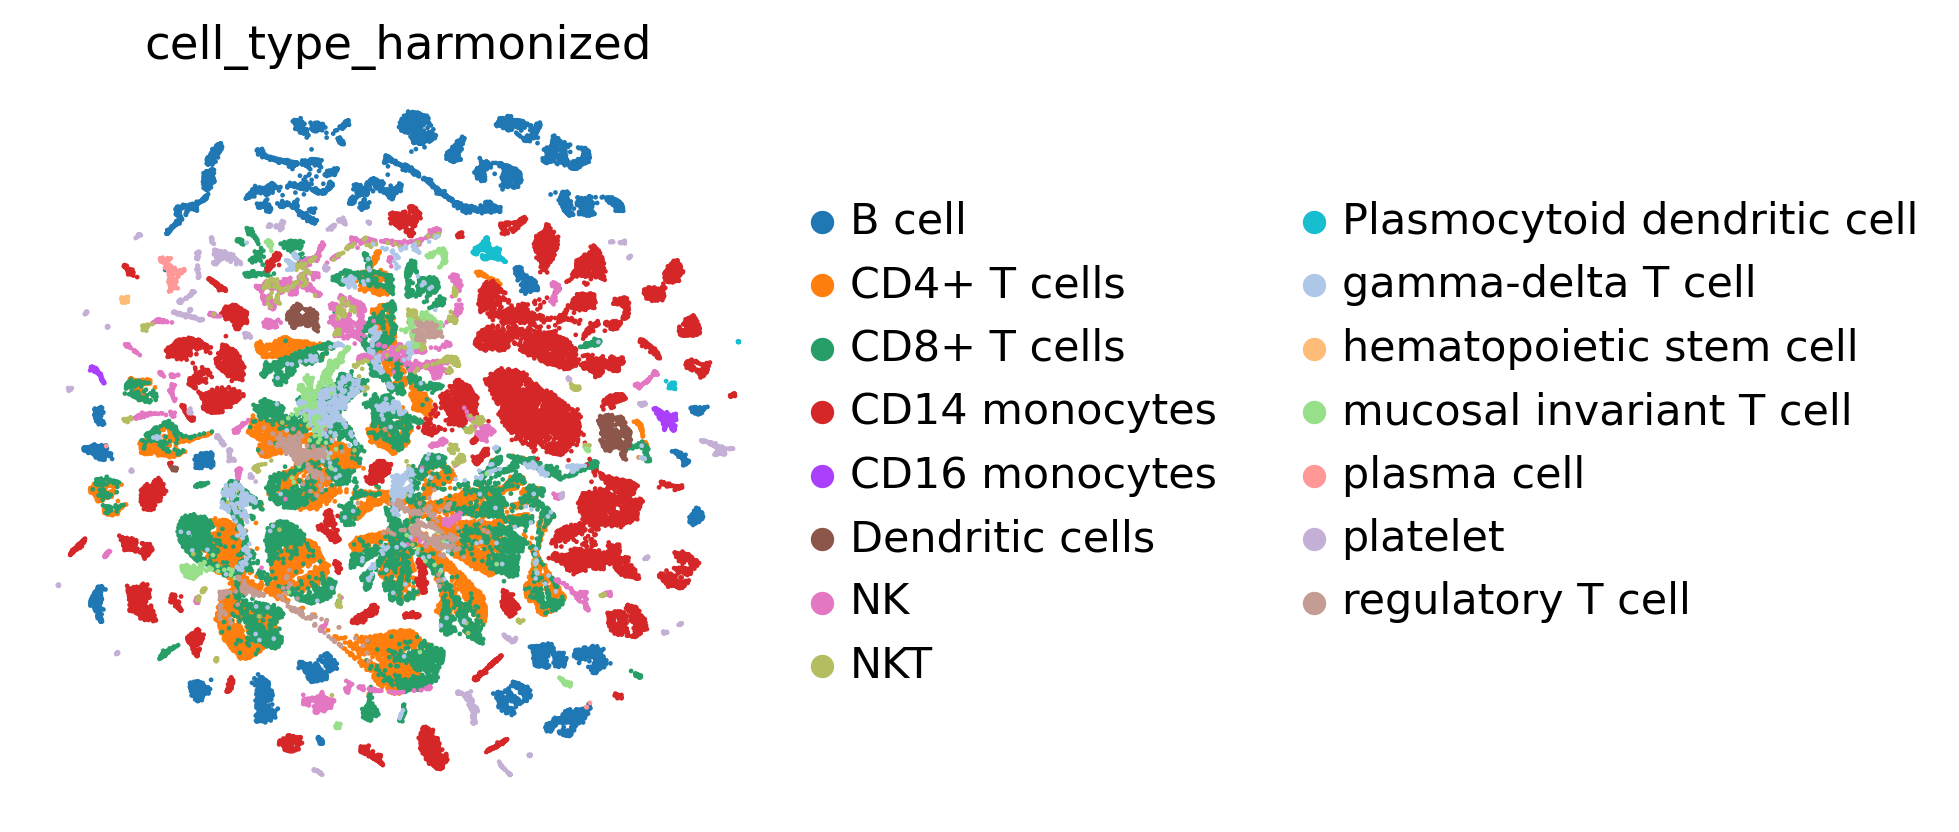

In [34]:
sc.pl.umap(adata_emb, color="cell_type_harmonized", frameon=False, size=8)


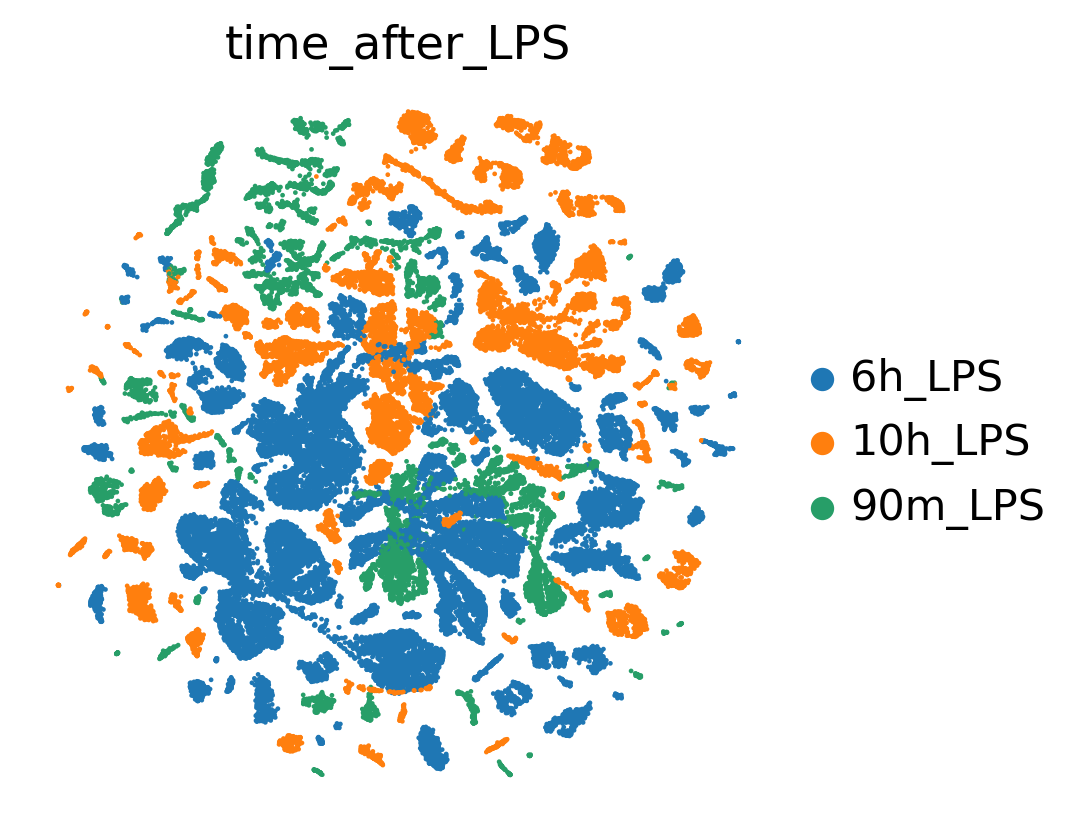

In [35]:
sc.pl.umap(adata_emb, color="time_after_LPS", frameon=False, size=8)
